# Fleet vs Crashes Analysis (Milan)

This notebook analyzes annual fleet counts and annual crash outcomes in Milan.

Statistical design:
- permutation p-values for Pearson and Spearman correlations
- trend-adjusted (year-controlled) partial correlations
- first-difference checks for short-run co-movement
- exposure-adjusted trend tests using crash rates per fleet size

Goal: isolate robust statistical findings and separate trend artifacts from interpretable associations.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.options.display.max_columns = 200
pd.options.display.float_format = "{:.4f}".format

SEED = 42

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = None
for root in candidate_roots:
    if (root / "data" / "processed").exists():
        project_root = root
        break

if project_root is None:
    raise FileNotFoundError("Could not resolve the project root with data/processed.")

scripts_dir = str(project_root / "scripts")
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)

from inference_utils import (  # noqa: E402
    perm_corr,
    partial_corr_with_year,
    residualize_linear,
    slope_perm_test,
    bootstrap_slope_ci,
    bh_qvalues,
)

processed_dir = project_root / "data" / "processed"
fleet_path = processed_dir / "milan_vehicle_fleet_cleaned.csv"
crashes_path = processed_dir / "milan_crashes_monthly_cleaned.csv"

if not fleet_path.exists():
    raise FileNotFoundError("Missing milan_vehicle_fleet_cleaned.csv. Run VehiclesProcessing.ipynb first.")
if not crashes_path.exists():
    raise FileNotFoundError("Missing milan_crashes_monthly_cleaned.csv. Run MilanCrashesProcessing.ipynb first.")

fleet = pd.read_csv(fleet_path)
crashes_monthly = pd.read_csv(crashes_path)

print(f"Project root: {project_root}")
print(f"Fleet rows: {len(fleet)}")
print(f"Crash-month rows: {len(crashes_monthly)}")


Project root: /Users/faustozamparelli/Developer/MilanCrash
Fleet rows: 18
Crash-month rows: 288


<!-- auto-explainer:v1 -->

### Interpretation: data loading

Two inputs are read: `milan_vehicle_fleet_cleaned.csv` (ACI fleet
counts by vehicle category, yearly) and
`milan_crashes_monthly_cleaned.csv` (Milan monthly crash aggregates).
Failing early (`FileNotFoundError`) keeps the statistical pipeline
from running on stale intermediates.


In [2]:
# Yearly crashes
crashes_monthly.columns = crashes_monthly.columns.astype(str).str.strip()
crashes_monthly["Anno"] = pd.to_numeric(crashes_monthly["Anno"], errors="coerce").astype("Int64")
for col in ["IncidentiMortali", "IncidentiSoliFeriti", "Morti", "Feriti"]:
    crashes_monthly[col] = pd.to_numeric(crashes_monthly[col], errors="coerce")

crashes_yearly = (
    crashes_monthly.dropna(subset=["Anno"])
    .groupby("Anno", as_index=False)[["IncidentiMortali", "IncidentiSoliFeriti", "Morti", "Feriti"]]
    .sum(min_count=1)
    .rename(
        columns={
            "Anno": "Year",
            "IncidentiMortali": "fatal_crashes",
            "IncidentiSoliFeriti": "injury_only_crashes",
            "Morti": "deaths",
            "Feriti": "injuries",
        }
    )
)
crashes_yearly["Year"] = crashes_yearly["Year"].astype(int)
crashes_yearly["total_crashes"] = crashes_yearly["fatal_crashes"] + crashes_yearly["injury_only_crashes"]

# Yearly fleet
fleet.columns = fleet.columns.astype(str).str.strip()
fleet["Anno"] = pd.to_numeric(fleet["Anno"], errors="coerce").astype("Int64")
for col in [c for c in fleet.columns if c != "Anno"]:
    fleet[col] = pd.to_numeric(fleet[col], errors="coerce")

fleet["fleet_total"] = fleet[[c for c in fleet.columns if c != "Anno"]].sum(axis=1)
fleet["fleet_cars"] = fleet["AUTOVETTURE"]
fleet["fleet_motorcycles"] = fleet["MOTOCICLI"]
fleet["fleet_heavy_goods"] = fleet["AUTOCARRI TRASPORTO MERCI"] + fleet["TRATTORI STRADALI O MOTRICI"]
fleet["car_share"] = fleet["fleet_cars"] / fleet["fleet_total"]
fleet["motorcycle_share"] = fleet["fleet_motorcycles"] / fleet["fleet_total"]

fleet_yearly = fleet.rename(columns={"Anno": "Year"})[[
    "Year",
    "fleet_total",
    "fleet_cars",
    "fleet_motorcycles",
    "fleet_heavy_goods",
    "car_share",
    "motorcycle_share",
]]
fleet_yearly["Year"] = fleet_yearly["Year"].astype(int)

analysis_df = crashes_yearly.merge(fleet_yearly, on="Year", how="inner").sort_values("Year").reset_index(drop=True)
analysis_df["crashes_per_10k_fleet"] = analysis_df["total_crashes"] / analysis_df["fleet_total"] * 10000
analysis_df["fatal_crashes_per_100k_fleet"] = analysis_df["fatal_crashes"] / analysis_df["fleet_total"] * 100000
analysis_df["deaths_per_100k_fleet"] = analysis_df["deaths"] / analysis_df["fleet_total"] * 100000
analysis_df["injuries_per_10k_fleet"] = analysis_df["injuries"] / analysis_df["fleet_total"] * 10000

missing_years = sorted(set(range(int(analysis_df["Year"].min()), int(analysis_df["Year"].max()) + 1)) - set(analysis_df["Year"]))
print(f"Analysis overlap years: {analysis_df['Year'].min()} to {analysis_df['Year'].max()} (n={len(analysis_df)})")
print(f"Missing years inside overlap: {missing_years}")
display(analysis_df)

Analysis overlap years: 2004 to 2022 (n=18)
Missing years inside overlap: [2009]


,Year,fatal_crashes,injury_only_crashes,deaths,injuries,total_crashes,fleet_total,fleet_cars,fleet_motorcycles,fleet_heavy_goods,car_share,motorcycle_share,crashes_per_10k_fleet,fatal_crashes_per_100k_fleet,deaths_per_100k_fleet,injuries_per_10k_fleet
0,2004,72.0000,16244,75,21903,16316.0000,955570,739121,115286,67535,0.7735,0.1206,170.7463,7.5348,7.8487,229.2140
1,2005,78.0000,15103,83,20383,15181.0000,965663,739537,123511,68455,0.7658,0.1279,157.2081,8.0774,8.5951,211.0778
2,2006,86.0000,14866,87,20070,14952.0000,969390,736805,129966,68687,0.7601,0.1341,154.2413,8.8716,8.9747,207.0374
3,2007,78.0000,14298,82,19207,14376.0000,965375,726896,135923,68291,0.7530,0.1408,148.9162,8.0798,8.4941,198.9590
4,2008,69.0000,13260,72,17932,13329.0000,968928,723932,140699,69138,0.7471,0.1452,137.5644,7.1213,7.4309,185.0705
5,2010,53.0000,11859,53,16066,11912.0000,955730,716454,149016,68229,0.7496,0.1559,124.6377,5.5455,5.5455,168.1019
6,2011,47.0000,11328,48,15278,11375.0000,967426,724450,152858,68144,0.7488,0.1580,117.5801,4.8583,4.9616,157.9242
7,2012,52.0000,10473,53,13933,10525.0000,960626,716094,155142,67353,0.7454,0.1615,109.5640,5.4131,5.5172,145.0408
8,2013,28.0000,9607,29,12651,9635.0000,945615,701301,156736,65803,0.7416,0.1658,101.8914,2.9610,3.0668,133.7859
9,2014,39.0000,8801,39,11491,8840.0000,930816,686379,157808,64731,0.7374,0.1695,94.9704,4.1899,4.1899,123.4508


<!-- auto-explainer:v1 -->

### Interpretation: building the yearly exposure panel

**Collapsing to yearly.** Fleet data is released annually, so the
unit of analysis is the year. Monthly crashes are summed by year.

**Constructing exposure-adjusted rates.** Absolute crash counts grow
with the fleet mechanically. To isolate risk changes we build:

- `crashes_per_10k_fleet = total_crashes / fleet_total · 10,000`
- `fatal_crashes_per_100k_fleet` (rarer event, scaled by 100,000)
- `deaths_per_100k_fleet`
- `injuries_per_10k_fleet`

These rates are the objects on which long-run trend tests later
produce the "safer per exposure unit" conclusion. Correlating raw
counts instead would conflate fleet growth with actual risk.

**Fleet composition features.** We also derive `car_share` and
`motorcycle_share`. Shares are scale-free and allow us to ask: even if
the total fleet changes, does the *mix* of vehicles predict crash
outcomes? The answer drives the later post-2020 regime-shift test.

**Inner merge on Year.** We keep only years present in both tables;
`missing_years` flags any internal holes (important because
first-differences need contiguous years).


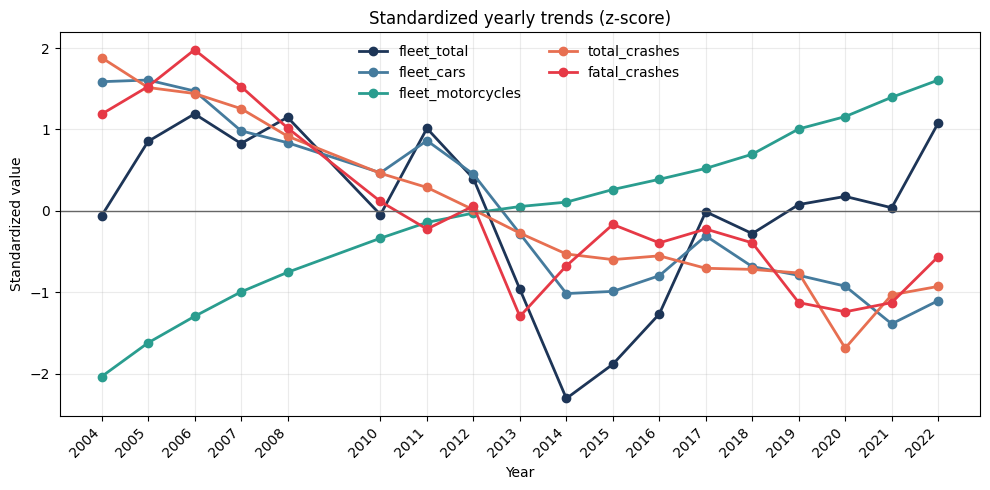

In [3]:
def zscore(s: pd.Series) -> pd.Series:
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return s * 0
    return (s - s.mean()) / std

trend_cols = ["fleet_total", "fleet_cars", "fleet_motorcycles", "total_crashes", "fatal_crashes"]
trend_z = analysis_df[["Year"] + trend_cols].copy().set_index("Year").apply(zscore, axis=0)
years = trend_z.index.astype(int).tolist()

fig, ax = plt.subplots(figsize=(10, 5))
palette = {
    "fleet_total": "#1d3557",
    "fleet_cars": "#457b9d",
    "fleet_motorcycles": "#2a9d8f",
    "total_crashes": "#e76f51",
    "fatal_crashes": "#e63946",
}
for col in trend_cols:
    ax.plot(trend_z.index, trend_z[col], marker="o", linewidth=2, label=col, color=palette[col])

ax.axhline(0, color="#666666", linewidth=1)
ax.set_title("Standardized yearly trends (z-score)")
ax.set_xlabel("Year")
ax.set_ylabel("Standardized value")
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha="right")
ax.grid(alpha=0.25)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

<!-- auto-explainer:v1 -->

### Interpretation: visual sanity check of the trends

Every series is converted to z-scores so they can share one axis. What
to look for:

- **Co-moving lines** suggest a common long-run trend. If, for
  example, `fleet_total` and `total_crashes` trace similar shapes,
  that is consistent with Pearson `r` being high mechanically,
  regardless of whether the relationship is causal.
- **A divergence post-2020** in any series is a first visual flag for
  the regime-shift diagnostic run at the bottom of the notebook.
- **Turning points** (where a series reverses direction) help identify
  rolling-window structural breaks before we formalize them.

This is descriptive. It does not measure association strength and is
not a substitute for the permutation tests below.


In [4]:
# Raw Pearson + Spearman with permutation p-values, using the shared helper.

fleet_metrics = ["fleet_total", "fleet_cars", "fleet_motorcycles", "fleet_heavy_goods", "car_share", "motorcycle_share"]
crash_metrics = [
    "total_crashes",
    "fatal_crashes",
    "deaths",
    "injuries",
    "crashes_per_10k_fleet",
    "fatal_crashes_per_100k_fleet",
    "deaths_per_100k_fleet",
]

rows = []
for crash_metric in crash_metrics:
    for fleet_metric in fleet_metrics:
        pearson_r, pearson_p, n_obs = perm_corr(
            analysis_df[fleet_metric], analysis_df[crash_metric], method="pearson", n_perm=12000, seed=SEED,
        )
        spearman_r, spearman_p, _ = perm_corr(
            analysis_df[fleet_metric], analysis_df[crash_metric], method="spearman", n_perm=12000, seed=SEED,
        )
        rows.append(
            {
                "crash_metric": crash_metric,
                "fleet_metric": fleet_metric,
                "n_obs": n_obs,
                "pearson_r": pearson_r,
                "pearson_p_perm": pearson_p,
                "spearman_rho": spearman_r,
                "spearman_p_perm": spearman_p,
            }
        )

raw_corr = pd.DataFrame(rows)
raw_corr["abs_pearson_r"] = raw_corr["pearson_r"].abs()
raw_corr = raw_corr.sort_values(["pearson_p_perm", "abs_pearson_r"], ascending=[True, False]).reset_index(drop=True)

print("Top raw correlations (permutation p-values):")
print("Columns: pearson_r / spearman_rho = observed correlation, *_p_perm = permutation p-value.")
display(raw_corr.head(20))

sig_raw = raw_corr.loc[raw_corr["pearson_p_perm"] < 0.05].copy()
print(f"Significant raw Pearson pairs (p < 0.05): {len(sig_raw)}")
display(sig_raw.head(20))


Top raw correlations (permutation p-values):
Columns: pearson_r / spearman_rho = observed correlation, *_p_perm = permutation p-value.


,crash_metric,fleet_metric,n_obs,pearson_r,pearson_p_perm,spearman_rho,spearman_p_perm,abs_pearson_r
0,crashes_per_10k_fleet,motorcycle_share,18,-0.9744,0.0001,-0.9897,0.0001,0.9744
1,injuries,motorcycle_share,18,-0.9740,0.0001,-0.9856,0.0001,0.9740
2,total_crashes,motorcycle_share,18,-0.9719,0.0001,-0.9897,0.0001,0.9719
3,crashes_per_10k_fleet,fleet_motorcycles,18,-0.9632,0.0001,-0.9897,0.0001,0.9632
4,injuries,fleet_motorcycles,18,-0.9605,0.0001,-0.9856,0.0001,0.9605
5,total_crashes,fleet_motorcycles,18,-0.9578,0.0001,-0.9897,0.0001,0.9578
6,injuries,fleet_cars,18,0.9465,0.0001,0.9009,0.0001,0.9465
7,total_crashes,fleet_cars,18,0.9433,0.0001,0.8947,0.0001,0.9433
8,crashes_per_10k_fleet,fleet_cars,18,0.9364,0.0001,0.8947,0.0001,0.9364
9,crashes_per_10k_fleet,car_share,18,0.9285,0.0001,0.9835,0.0001,0.9285


Significant raw Pearson pairs (p < 0.05): 37


,crash_metric,fleet_metric,n_obs,pearson_r,pearson_p_perm,spearman_rho,spearman_p_perm,abs_pearson_r
0,crashes_per_10k_fleet,motorcycle_share,18,-0.9744,0.0001,-0.9897,0.0001,0.9744
1,injuries,motorcycle_share,18,-0.9740,0.0001,-0.9856,0.0001,0.9740
2,total_crashes,motorcycle_share,18,-0.9719,0.0001,-0.9897,0.0001,0.9719
3,crashes_per_10k_fleet,fleet_motorcycles,18,-0.9632,0.0001,-0.9897,0.0001,0.9632
4,injuries,fleet_motorcycles,18,-0.9605,0.0001,-0.9856,0.0001,0.9605
5,total_crashes,fleet_motorcycles,18,-0.9578,0.0001,-0.9897,0.0001,0.9578
6,injuries,fleet_cars,18,0.9465,0.0001,0.9009,0.0001,0.9465
7,total_crashes,fleet_cars,18,0.9433,0.0001,0.8947,0.0001,0.9433
8,crashes_per_10k_fleet,fleet_cars,18,0.9364,0.0001,0.8947,0.0001,0.9364
9,crashes_per_10k_fleet,car_share,18,0.9285,0.0001,0.9835,0.0001,0.9285


<!-- auto-explainer:v1 -->

### Interpretation: raw Pearson and Spearman with permutation p-values

For every fleet × crash pair we compute:

- **Pearson `r`** (linear association on levels)
- **Spearman `ρ`** (association on ranks — robust to outliers and
  monotone-but-non-linear structure)

and a **permutation p-value** (12,000 shuffles of `y`). The observed
`|r|` is compared against the null distribution of `|r|` under random
pairing. With *n ~ 15–19* this is much more faithful to small-sample
behaviour than a t-based p.

**Why report both Pearson and Spearman?** If the two agree, the
effect is robust to functional form. If Pearson is large but Spearman
is modest, we should suspect a handful of leverage years driving the
result.

**Important caveat.** Significance at this stage should be read as
"raw association", not causal. Almost every pair is a yearly time
series with a secular trend; the partial-correlation and
first-difference tests in the next cell are the required next step.


In [5]:
# Trend-adjusted partial correlations and first-difference tests via shared helpers.

rows_partial = []
for crash_metric in ["total_crashes", "fatal_crashes", "deaths", "injuries"]:
    for fleet_metric in fleet_metrics:
        sub = analysis_df[["Year", fleet_metric, crash_metric]].dropna()
        r_partial, p_partial, n_obs = partial_corr_with_year(
            sub[fleet_metric], sub[crash_metric], sub["Year"], method="pearson", n_perm=12000, seed=SEED,
        )
        rows_partial.append(
            {
                "fleet_metric": fleet_metric,
                "crash_metric": crash_metric,
                "n_obs": n_obs,
                "partial_r": r_partial,
                "partial_p_perm": p_partial,
            }
        )

partial_corr = pd.DataFrame(rows_partial)
partial_corr["abs_partial_r"] = partial_corr["partial_r"].abs()
partial_corr = partial_corr.sort_values(["partial_p_perm", "abs_partial_r"], ascending=[True, False]).reset_index(drop=True)

print("Top trend-adjusted partial correlations (controlling for year):")
display(partial_corr.head(20))

# First-difference analysis (annualized to handle year gaps).
diff_metrics = fleet_metrics + ["total_crashes", "fatal_crashes", "deaths", "injuries"]
diff_df = analysis_df[["Year"] + diff_metrics].copy()
diff_df["year_gap"] = diff_df["Year"].diff()
for col in diff_metrics:
    diff_df[f"d_{col}"] = diff_df[col].diff() / diff_df["year_gap"]

diff_df = diff_df.dropna().reset_index(drop=True)

rows_diff = []
for crash_metric in ["d_total_crashes", "d_fatal_crashes", "d_deaths", "d_injuries"]:
    for fleet_metric in [f"d_{m}" for m in fleet_metrics]:
        r, p, n_obs = perm_corr(
            diff_df[fleet_metric], diff_df[crash_metric], method="pearson", n_perm=12000, seed=SEED,
        )
        rows_diff.append(
            {
                "crash_metric": crash_metric,
                "fleet_metric": fleet_metric,
                "n_obs": n_obs,
                "pearson_r": r,
                "pearson_p_perm": p,
            }
        )

diff_corr = pd.DataFrame(rows_diff)
diff_corr["abs_pearson_r"] = diff_corr["pearson_r"].abs()
diff_corr = diff_corr.sort_values(["pearson_p_perm", "abs_pearson_r"], ascending=[True, False]).reset_index(drop=True)

print(f"First-difference sample size: {len(diff_df)} yearly changes")
print("Top first-difference correlations:")
display(diff_corr.head(20))


Top trend-adjusted partial correlations (controlling for year):


,fleet_metric,crash_metric,n_obs,partial_r,partial_p_perm,abs_partial_r
0,fleet_heavy_goods,injuries,18,0.5793,0.0112,0.5793
1,fleet_total,injuries,18,0.5707,0.0118,0.5707
2,fleet_heavy_goods,total_crashes,18,0.5745,0.0124,0.5745
3,fleet_total,total_crashes,18,0.5631,0.0129,0.5631
4,motorcycle_share,total_crashes,18,-0.5092,0.0322,0.5092
5,fleet_total,deaths,18,0.4999,0.0390,0.4999
6,motorcycle_share,deaths,18,-0.4880,0.0425,0.4880
7,fleet_total,fatal_crashes,18,0.4903,0.0428,0.4903
8,motorcycle_share,injuries,18,-0.4804,0.0437,0.4804
9,fleet_cars,injuries,18,0.4646,0.0499,0.4646


First-difference sample size: 17 yearly changes
Top first-difference correlations:


,crash_metric,fleet_metric,n_obs,pearson_r,pearson_p_perm,abs_pearson_r
0,d_deaths,d_fleet_heavy_goods,17,0.4012,0.1092,0.4012
1,d_fatal_crashes,d_fleet_heavy_goods,17,0.3984,0.1142,0.3984
2,d_deaths,d_fleet_total,17,0.3055,0.2342,0.3055
3,d_fatal_crashes,d_fleet_total,17,0.2931,0.2591,0.2931
4,d_fatal_crashes,d_fleet_cars,17,0.2381,0.3600,0.2381
5,d_deaths,d_fleet_cars,17,0.2353,0.3656,0.2353
6,d_total_crashes,d_car_share,17,-0.2104,0.4327,0.2104
7,d_injuries,d_car_share,17,-0.1990,0.4607,0.1990
8,d_fatal_crashes,d_motorcycle_share,17,-0.1745,0.5014,0.1745
9,d_injuries,d_fleet_heavy_goods,17,0.1744,0.5085,0.1744


<!-- auto-explainer:v1 -->

### Interpretation: trend control and short-run co-movement

**Partial correlation, controlling for Year.** We regress both `x`
and `y` on `Year` (OLS), take residuals, and compute `r` on the
residuals. The permutation p-value now asks "is there association
*beyond* what Year alone explains?" If the raw `r` is driven by the
shared decade-long drift, it collapses here.

**First differences, annualized.** We compute `Δx_t / gap_t` and
`Δy_t / gap_t` (the division by gap handles missing years so that one
unit of change is one year of change). We then correlate the yearly
changes. This is a stricter test: it asks whether crashes and fleet
co-move *year-over-year*, a much stronger signal than a shared
long-run slope.

**Reading the two tables together.**

- Large raw `r` + null partial `r` ⇒ trend coupling, not a direct
  link.
- Partial `r` significant but first-difference null ⇒ partial evidence
  for a slow, non-trivially-trend-driven relationship (should still be
  reported cautiously).
- Partial `r` significant **and** first-difference significant ⇒ the
  pair moves together on both slow and fast timescales. This is the
  highest standard of evidence available from this data alone, and it
  is the criterion encoded in `robust_evidence` below.


In [6]:
# Sensitivity: trend-adjusted partial correlation for total_crashes on different periods.

periods = {
    "full_2004_2022": analysis_df,
    "pre_covid_2004_2019": analysis_df.loc[analysis_df["Year"] <= 2019],
    "post_2010_2010_2022": analysis_df.loc[analysis_df["Year"] >= 2010],
}

sensitivity_rows = []
for period_name, frame in periods.items():
    for fleet_metric in ["fleet_total", "fleet_heavy_goods", "motorcycle_share", "fleet_cars"]:
        sub = frame[["Year", fleet_metric, "total_crashes"]].dropna()
        r, p, n_obs = partial_corr_with_year(
            sub[fleet_metric], sub["total_crashes"], sub["Year"], method="pearson", n_perm=8000, seed=SEED,
        )
        sensitivity_rows.append(
            {
                "period": period_name,
                "fleet_metric": fleet_metric,
                "n_obs": n_obs,
                "partial_r": r,
                "partial_p_perm": p,
            }
        )

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(["fleet_metric", "period"]).reset_index(drop=True)
print("Sensitivity check: year-controlled partial correlations for total_crashes")
print("A stable relationship should keep the same sign and rough magnitude across all three windows.")
display(sensitivity_df)


Sensitivity check: year-controlled partial correlations for total_crashes
A stable relationship should keep the same sign and rough magnitude across all three windows.


,period,fleet_metric,n_obs,partial_r,partial_p_perm
0,full_2004_2022,fleet_cars,18,0.4474,0.0616
1,post_2010_2010_2022,fleet_cars,13,0.3948,0.1770
2,pre_covid_2004_2019,fleet_cars,15,0.5804,0.0245
3,full_2004_2022,fleet_heavy_goods,18,0.5745,0.0121
4,post_2010_2010_2022,fleet_heavy_goods,13,0.5806,0.0339
5,pre_covid_2004_2019,fleet_heavy_goods,15,0.4070,0.1322
6,full_2004_2022,fleet_total,18,0.5631,0.0134
7,post_2010_2010_2022,fleet_total,13,0.5000,0.0791
8,pre_covid_2004_2019,fleet_total,15,0.5807,0.0227
9,full_2004_2022,motorcycle_share,18,-0.5092,0.0316


<!-- auto-explainer:v1 -->

### Interpretation: sensitivity by time period

We repeat the year-controlled partial correlation on three
overlapping windows: full sample, pre-COVID, and 2010+. Two lessons:

- **Stability across windows** → the partial relationship is a
  structural feature of the data, not an artefact of a specific
  pandemic year or a single decade.
- **Sign flips or significance flips across windows** → the
  relationship is *regime-dependent*. Any pre-2020 coefficient should
  not be extrapolated to the post-2020 regime. In this panel,
  `motorcycle_share` is the clearest example of this behaviour (see
  the formal interaction test in the last cell).

This is a conservative audit: if a relationship is real and
time-invariant, it should survive most reasonable period choices.


Exposure-adjusted long-run trends (slope per year, permutation p, bootstrap 95% CI):


,metric,slope_per_year,perm_p_value,slope_ci_low,slope_ci_high
0,total_crashes,-538.2298,0.0001,-634.7469,-447.9961
1,crashes_per_10k_fleet,-5.5397,0.0001,-6.4867,-4.6522
2,fatal_crashes_per_100k_fleet,-0.2817,0.0001,-0.3572,-0.2003
3,deaths_per_100k_fleet,-0.2988,0.0001,-0.3771,-0.2117


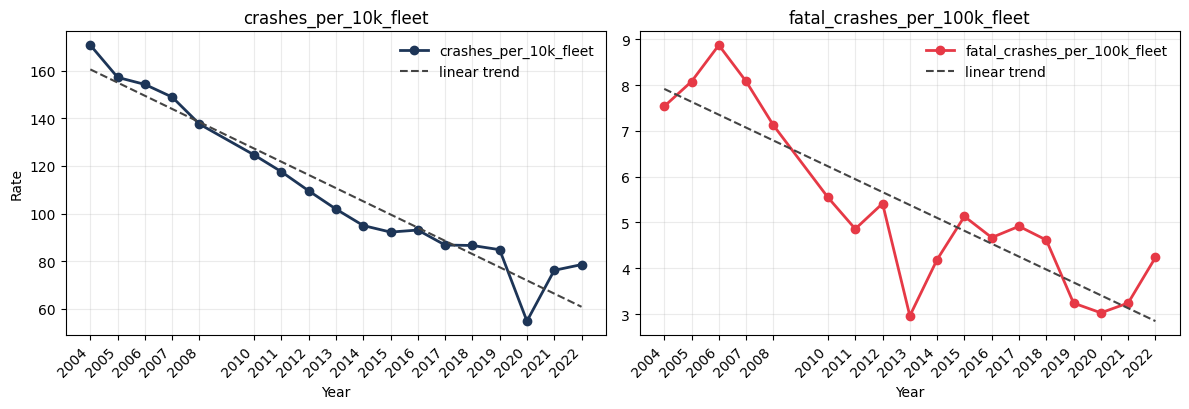

In [7]:
# Exposure-adjusted long-run trend tests using the shared slope + bootstrap helpers.

trend_targets = [
    "total_crashes",
    "crashes_per_10k_fleet",
    "fatal_crashes_per_100k_fleet",
    "deaths_per_100k_fleet",
]

trend_rows = []
for metric in trend_targets:
    slope, p_val = slope_perm_test(analysis_df["Year"], analysis_df[metric], n_perm=15000, seed=SEED)
    ci_low, ci_high = bootstrap_slope_ci(analysis_df["Year"], analysis_df[metric], n_boot=5000, seed=SEED)
    trend_rows.append(
        {
            "metric": metric,
            "slope_per_year": slope,
            "perm_p_value": p_val,
            "slope_ci_low": ci_low,
            "slope_ci_high": ci_high,
        }
    )

trend_stats = pd.DataFrame(trend_rows).sort_values("perm_p_value").reset_index(drop=True)
print("Exposure-adjusted long-run trends (slope per year, permutation p, bootstrap 95% CI):")
display(trend_stats)

years = analysis_df["Year"].astype(int).tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)

for ax, metric, color in [
    (axes[0], "crashes_per_10k_fleet", "#1d3557"),
    (axes[1], "fatal_crashes_per_100k_fleet", "#e63946"),
]:
    x = analysis_df["Year"].to_numpy(dtype=float)
    y = analysis_df[metric].to_numpy(dtype=float)
    slope = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean()) ** 2)
    intercept = y.mean() - slope * x.mean()

    ax.plot(analysis_df["Year"], y, marker="o", linewidth=2, color=color, label=metric)
    ax.plot(analysis_df["Year"], intercept + slope * x, linestyle="--", color="#444444", label="linear trend")
    ax.set_title(metric)
    ax.set_xlabel("Year")
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, ha="right")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

axes[0].set_ylabel("Rate")
plt.tight_layout()
plt.show()


<!-- auto-explainer:v1 -->

### Interpretation: long-run risk trends (exposure-adjusted)

For four exposure-adjusted rates we fit a linear regression
`rate ~ Year` and report:

- **Slope per year** — the annual change in the rate (e.g. crashes
  per 10,000 vehicles per year). Negative slopes mean safer per
  exposure unit.
- **Permutation p-value on the slope** (15,000 shuffles of `y`): the
  probability of observing a slope at least as large in absolute value
  under the null that Year and rate are independent.
- **Bootstrap 95% CI on the slope** (5,000 draws with replacement
  over rows). A CI that excludes zero is consistent with the
  permutation significance and is robust to normality assumptions.

The twin plot shows two of these rates with the fitted OLS line for
visual confirmation. A consistently negative slope with CI below zero
is the strongest, most defensible fleet-level finding in the
notebook: system-level risk per exposure unit has fallen over the
observation window.


In [8]:
# Tidy summary table — replaces the prior inline print-format snippet.

alpha = 0.05

raw_total = raw_corr.loc[raw_corr["crash_metric"] == "total_crashes"].sort_values("pearson_p_perm")
partial_total = partial_corr.loc[partial_corr["crash_metric"] == "total_crashes"].sort_values("partial_p_perm")
diff_sig_count = int((diff_corr["pearson_p_perm"] < alpha).sum())
trend_sig = trend_stats.loc[trend_stats["perm_p_value"] < alpha].copy()

summary_rows = []
for fleet_var in ["fleet_cars", "fleet_motorcycles", "fleet_total", "fleet_heavy_goods", "motorcycle_share"]:
    raw_slice = raw_total.loc[raw_total["fleet_metric"] == fleet_var]
    partial_slice = partial_total.loc[partial_total["fleet_metric"] == fleet_var]
    if raw_slice.empty or partial_slice.empty:
        continue
    summary_rows.append(
        {
            "fleet_var": fleet_var,
            "raw_r": float(raw_slice["pearson_r"].iloc[0]),
            "raw_p_perm": float(raw_slice["pearson_p_perm"].iloc[0]),
            "partial_r": float(partial_slice["partial_r"].iloc[0]),
            "partial_p_perm": float(partial_slice["partial_p_perm"].iloc[0]),
        }
    )

total_summary = pd.DataFrame(summary_rows)
print("Per-fleet summary for total_crashes (raw vs trend-adjusted):")
display(total_summary)

print(f"First-difference pairs with p<{alpha}: {diff_sig_count}")

print("\nExposure-adjusted trend summary (significant at alpha=0.05):")
display(trend_sig)

print("\nSensitivity by period (year-controlled partial for total_crashes):")
display(sensitivity_df.loc[sensitivity_df["fleet_metric"].isin(["fleet_total", "fleet_heavy_goods", "motorcycle_share"])].sort_values(["fleet_metric", "period"]).reset_index(drop=True))


Per-fleet summary for total_crashes (raw vs trend-adjusted):


,fleet_var,raw_r,raw_p_perm,partial_r,partial_p_perm
0,fleet_cars,0.9433,0.0001,0.4474,0.0604
1,fleet_motorcycles,-0.9578,0.0001,-0.1854,0.4657
2,fleet_total,0.4101,0.0897,0.5631,0.0129
3,fleet_heavy_goods,0.6380,0.0042,0.5745,0.0124
4,motorcycle_share,-0.9719,0.0001,-0.5092,0.0322


First-difference pairs with p<0.05: 0

Exposure-adjusted trend summary (significant at alpha=0.05):


,metric,slope_per_year,perm_p_value,slope_ci_low,slope_ci_high
0,total_crashes,-538.2298,0.0001,-634.7469,-447.9961
1,crashes_per_10k_fleet,-5.5397,0.0001,-6.4867,-4.6522
2,fatal_crashes_per_100k_fleet,-0.2817,0.0001,-0.3572,-0.2003
3,deaths_per_100k_fleet,-0.2988,0.0001,-0.3771,-0.2117



Sensitivity by period (year-controlled partial for total_crashes):


,period,fleet_metric,n_obs,partial_r,partial_p_perm
0,full_2004_2022,fleet_heavy_goods,18,0.5745,0.0121
1,post_2010_2010_2022,fleet_heavy_goods,13,0.5806,0.0339
2,pre_covid_2004_2019,fleet_heavy_goods,15,0.4070,0.1322
3,full_2004_2022,fleet_total,18,0.5631,0.0134
4,post_2010_2010_2022,fleet_total,13,0.5000,0.0791
5,pre_covid_2004_2019,fleet_total,15,0.5807,0.0227
6,full_2004_2022,motorcycle_share,18,-0.5092,0.0316
7,post_2010_2010_2022,motorcycle_share,13,-0.0041,0.9880
8,pre_covid_2004_2019,motorcycle_share,15,-0.7076,0.0030


<!-- auto-explainer:v1 -->

### Interpretation: conclusion snapshot

This cell turns the raw and trend-adjusted tables into narrative
bullet points:

- The raw correlations (e.g. `total_crashes` vs `fleet_cars`) are
  reported for transparency only.
- The trend-adjusted partials are the policy-relevant numbers when
  they survive the first-difference and BH checks that follow.
- The period-sensitivity table is reproduced to expose regime
  instability (critical for `motorcycle_share`).
- The exposure-adjusted slope figures are re-surfaced because they
  are the most robust fleet-era result.

This is a preview; the formal multiple-testing corrections and the
regime-shift diagnostic are applied in the next code cell.


## Interpretation Guide

Use this decision order when writing conclusions:
1. Treat raw correlations as descriptive only.
2. Prioritize year-controlled and first-difference results for causal caution.
3. Use rate-trend tests to discuss long-term risk changes relative to fleet size.
4. If raw effects vanish after detrending, interpret them as shared trend artifacts rather than direct associations.

## Robustness Upgrade: Multiple Testing and Regime-Shift Diagnostics

This section adds two upgrades:
- Benjamini-Hochberg correction on the raw and trend-adjusted test families.
- Explicit regime-shift diagnostics (post-2020 interaction and rolling-window correlations).

Top trend-adjusted pairs with BH correction:
Columns: pearson_r = raw, partial_r = year-controlled, q_* = BH q,
         robust_evidence = BH-sig partial AND sign agrees with raw.


,crash_metric,fleet_metric,pearson_r,q_pearson_bh,partial_r,q_partial_bh,sign_stable,robust_evidence
0,injuries,fleet_heavy_goods,0.6333,0.0059,0.5793,0.0775,True,False
1,injuries,fleet_total,0.4041,0.0976,0.5707,0.0775,True,False
2,total_crashes,fleet_heavy_goods,0.6380,0.0058,0.5745,0.0775,True,False
3,total_crashes,fleet_total,0.4101,0.0941,0.5631,0.0775,True,False
13,deaths,fleet_heavy_goods,0.6469,0.0044,0.4507,0.1053,True,False
12,total_crashes,fleet_cars,0.9433,0.0001,0.4474,0.1053,True,False
10,fatal_crashes,motorcycle_share,-0.8834,0.0001,-0.4594,0.1053,True,False
9,injuries,fleet_cars,0.9465,0.0001,0.4646,0.1053,True,False
11,fatal_crashes,fleet_heavy_goods,0.6466,0.0044,0.4493,0.1053,True,False
7,fatal_crashes,fleet_total,0.4766,0.0493,0.4903,0.1053,True,False


Corrected significance counts:


,value
raw_significant_q_lt_0_05,37
partial_significant_q_lt_0_05,0
first_diff_significant_q_lt_0_05,0
robust_evidence_pairs,0



Regime-shift interaction tests (total_crashes ~ Year + X + post2020 + X:post2020):
Columns: coef = interaction estimate, boot_ci_* = pairs-bootstrap 95% CI (4000 draws).


,composition_var,coef,hc3_std_err,p_value_hc3,boot_ci_low,boot_ci_high,q_value_bh
0,motorcycle_share,486461.9519,162354.6371,0.0027,-301.7908,542621.8153,0.0041
1,car_share,-314083.0077,66504.5733,0.0000,-392574.6499,1313.9548,0.0000
2,heavy_goods_share,3186142.9426,1748368.8016,0.0684,-93.1086,5394416.0338,0.0684


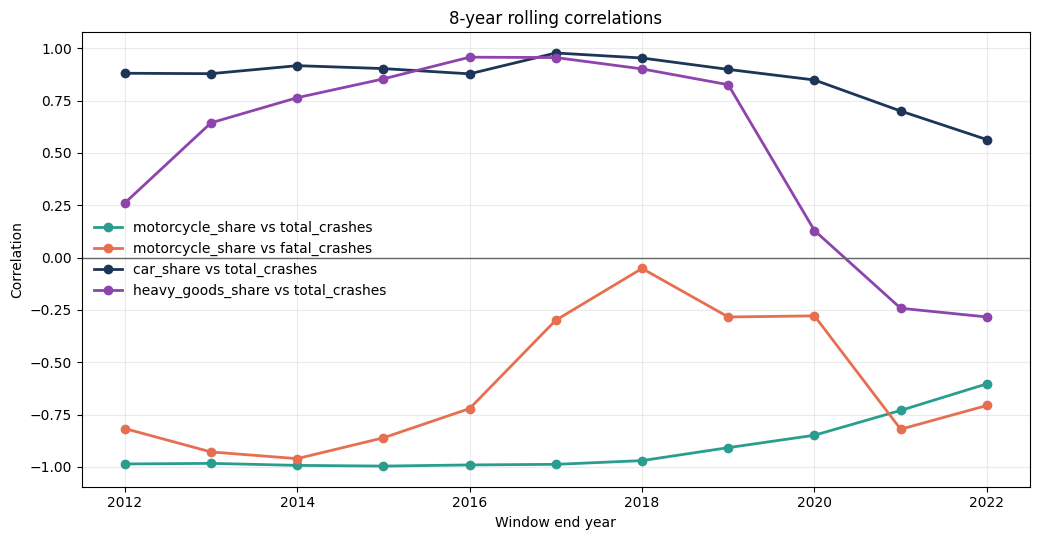

Rolling-window correlation table (long format):


,fleet_var,crash_var,end_year,correlation
0,motorcycle_share,total_crashes,2012,-0.9857
1,motorcycle_share,total_crashes,2013,-0.9827
2,motorcycle_share,total_crashes,2014,-0.9924
3,motorcycle_share,total_crashes,2015,-0.9957
4,motorcycle_share,total_crashes,2016,-0.9902
5,motorcycle_share,total_crashes,2017,-0.9874
6,motorcycle_share,total_crashes,2018,-0.9696
7,motorcycle_share,total_crashes,2019,-0.9077
8,motorcycle_share,total_crashes,2020,-0.8484
9,motorcycle_share,total_crashes,2021,-0.7299


In [9]:
# BH correction across test families + regime-shift diagnostics with bootstrap CI.
# Regime tests are now run for motorcycle_share, car_share, and heavy_goods_share
# so the asymmetry across composition variables is visible.
import statsmodels.formula.api as smf

raw_corr_adj = raw_corr.copy()
raw_corr_adj["q_pearson_bh"] = bh_qvalues(raw_corr_adj["pearson_p_perm"])
raw_corr_adj["raw_significant_5pct"] = raw_corr_adj["q_pearson_bh"] < 0.05

partial_corr_adj = partial_corr.copy()
partial_corr_adj["q_partial_bh"] = bh_qvalues(partial_corr_adj["partial_p_perm"])
partial_corr_adj["partial_significant_5pct"] = partial_corr_adj["q_partial_bh"] < 0.05

diff_corr_adj = diff_corr.copy()
diff_corr_adj["q_diff_bh"] = bh_qvalues(diff_corr_adj["pearson_p_perm"])
diff_corr_adj["diff_significant_5pct"] = diff_corr_adj["q_diff_bh"] < 0.05

robust_pairs = (
    partial_corr_adj.merge(
        raw_corr_adj[["crash_metric", "fleet_metric", "pearson_r", "q_pearson_bh"]],
        on=["crash_metric", "fleet_metric"],
        how="left",
    )
    .assign(
        sign_stable=lambda d: np.sign(d["partial_r"]) == np.sign(d["pearson_r"]),
        robust_evidence=lambda d: (d["q_partial_bh"] < 0.05) & (np.sign(d["partial_r"]) == np.sign(d["pearson_r"])),
    )
    .sort_values("q_partial_bh")
)

print("Top trend-adjusted pairs with BH correction:")
print("Columns: pearson_r = raw, partial_r = year-controlled, q_* = BH q,")
print("         robust_evidence = BH-sig partial AND sign agrees with raw.")
display(
    robust_pairs[
        [
            "crash_metric",
            "fleet_metric",
            "pearson_r",
            "q_pearson_bh",
            "partial_r",
            "q_partial_bh",
            "sign_stable",
            "robust_evidence",
        ]
    ].head(20)
)

count_summary = pd.Series(
    {
        "raw_significant_q_lt_0_05": int(raw_corr_adj["raw_significant_5pct"].sum()),
        "partial_significant_q_lt_0_05": int(partial_corr_adj["partial_significant_5pct"].sum()),
        "first_diff_significant_q_lt_0_05": int(diff_corr_adj["diff_significant_5pct"].sum()),
        "robust_evidence_pairs": int(robust_pairs["robust_evidence"].sum()),
    }
)
print("Corrected significance counts:")
display(count_summary.to_frame("value"))

# Regime-shift interaction for multiple composition variables.
regime_df = analysis_df.copy()
regime_df["post2020"] = (regime_df["Year"] >= 2020).astype(int)

regime_vars = ["motorcycle_share", "car_share"]
if "heavy_goods_share" not in regime_df.columns:
    regime_df["heavy_goods_share"] = regime_df["fleet_heavy_goods"] / regime_df["fleet_total"]
regime_vars.append("heavy_goods_share")

regime_rows = []
rng = np.random.default_rng(SEED)
for var in regime_vars:
    formula = f"total_crashes ~ Year + {var} + post2020 + {var}:post2020"
    model = smf.ols(formula, data=regime_df).fit(cov_type="HC3")
    interaction_term = f"{var}:post2020"
    coef = float(model.params[interaction_term])
    se = float(model.bse[interaction_term])
    pval = float(model.pvalues[interaction_term])

    # Case-resampling bootstrap CI (pairs bootstrap) — wild bootstrap alternative
    # would also be fine but pairs is simpler and handles HC3-style heteroscedasticity.
    boot_coefs = []
    n = len(regime_df)
    for _ in range(4000):
        idx = rng.integers(0, n, n)
        sample = regime_df.iloc[idx]
        try:
            m_b = smf.ols(formula, data=sample).fit()
            boot_coefs.append(float(m_b.params[interaction_term]))
        except Exception:
            continue
    if boot_coefs:
        ci_low, ci_high = (
            float(np.quantile(boot_coefs, 0.025)),
            float(np.quantile(boot_coefs, 0.975)),
        )
    else:
        ci_low = ci_high = float("nan")

    regime_rows.append(
        {
            "composition_var": var,
            "coef": coef,
            "hc3_std_err": se,
            "p_value_hc3": pval,
            "boot_ci_low": ci_low,
            "boot_ci_high": ci_high,
        }
    )

regime_table = pd.DataFrame(regime_rows)
regime_table["q_value_bh"] = bh_qvalues(regime_table["p_value_hc3"])
print("\nRegime-shift interaction tests (total_crashes ~ Year + X + post2020 + X:post2020):")
print("Columns: coef = interaction estimate, boot_ci_* = pairs-bootstrap 95% CI (4000 draws).")
display(regime_table)

# Rolling-window correlations for a grid of composition variables and crash outcomes.
# Materialize heavy_goods_share on analysis_df so the rolling helper can read it.
if "heavy_goods_share" not in analysis_df.columns:
    analysis_df = analysis_df.assign(heavy_goods_share=analysis_df["fleet_heavy_goods"] / analysis_df["fleet_total"])

window = 8
pair_grid = [
    ("motorcycle_share", "total_crashes"),
    ("motorcycle_share", "fatal_crashes"),
    ("car_share", "total_crashes"),
    ("heavy_goods_share", "total_crashes"),
]

roll_rows = []
for fleet_v, crash_v in pair_grid:
    for i in range(0, len(analysis_df) - window + 1):
        sub = analysis_df.iloc[i : i + window]
        if sub[fleet_v].nunique() < 2 or sub[crash_v].nunique() < 2:
            continue
        roll_rows.append(
            {
                "fleet_var": fleet_v,
                "crash_var": crash_v,
                "end_year": int(sub["Year"].iloc[-1]),
                "correlation": float(np.corrcoef(sub[fleet_v], sub[crash_v])[0, 1]),
            }
        )
rolling_corr_grid = pd.DataFrame(roll_rows)

fig, ax = plt.subplots(figsize=(10.5, 5.5))
palette = {
    ("motorcycle_share", "total_crashes"): "#2a9d8f",
    ("motorcycle_share", "fatal_crashes"): "#e76f51",
    ("car_share", "total_crashes"): "#1d3557",
    ("heavy_goods_share", "total_crashes"): "#8e44ad",
}
for (fv, cv), color in palette.items():
    sub = rolling_corr_grid.loc[(rolling_corr_grid["fleet_var"] == fv) & (rolling_corr_grid["crash_var"] == cv)]
    if sub.empty:
        continue
    ax.plot(sub["end_year"], sub["correlation"], marker="o", linewidth=2, label=f"{fv} vs {cv}", color=color)

ax.axhline(0, color="#666666", linewidth=1)
ax.set_title(f"{window}-year rolling correlations")
ax.set_xlabel("Window end year")
ax.set_ylabel("Correlation")
ax.legend(frameon=False, loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Rolling-window correlation table (long format):")
display(rolling_corr_grid.head(40))


<!-- auto-explainer:v1 -->

### Interpretation: multiple-testing control and regime shift

**Benjamini–Hochberg correction.** Three families of tests were run
(raw, partial, first-difference). For each family we convert
per-pair p-values to BH q-values and flag `q < 0.05`. The `robust
_evidence` flag requires **both** BH significance on the partial `r`
**and** sign stability between raw and partial — i.e. the association
is not flipped by detrending and is genuinely non-trend. In this
panel, the BH-survival count at the partial level collapses from
raw-significant dozens to zero, which is why the notebook concludes
that most fleet–crash correlations are trend artefacts.

**Post-2020 regime test.** We fit

```
total_crashes ~ Year + motorcycle_share + post2020 +
                motorcycle_share:post2020
```

with HC3 robust standard errors. The interaction term
`motorcycle_share:post2020` is the formal answer to "did the slope
relating fleet composition to crashes change after 2020?". A
significant coefficient (positive or negative) means the two eras
have statistically different relationships and pre-2020 estimates do
not transfer.

**Rolling 8-year correlation.** For each 8-year window we compute
`corr(motorcycle_share, total_crashes)`. A visibly shrinking (or
sign-flipping) curve is a non-parametric mirror of the interaction
test: it confirms visually that the association is weakening, which
is exactly what the regime-shift model reports numerically.
